# Volume/Attention Rotation Engine — Stocks + Crypto

**Pipeline, in the order requested:**

1. **Volume/attention ranking** — rank the universe by *relative* volume increase (short vs.
   long rolling average), not absolute volume. A mega-cap always has more absolute volume than
   a small name; what signals "attention" is whether today's volume is unusual *for that name*.
2. **Bucket-list filter** — restrict candidates to a pre-vetted universe: the 28-name
   sector-diverse stock set used throughout this session, plus a crypto majors list
   (`BTC, ETH, SOL, ADA, XRP, LTC`) taken directly from the prop-firm source material's own
   recommended crypto bucket.
3. **Beta-rotation regime overlay** (reused from the main engine: `XLY/XLP`, `XLU/SPY`,
   `RSP/SPY`) scales tranche size with the macro regime.
4. **Momentum + ensemble selection** — the TEMA+MACD ensemble (from the standalone crypto
   notebook, generalized to any asset) is a **hard gate**: only names currently in a bullish
   ensemble state are eligible at all. Among those, rank by momentum and take the top N.
5. **Position building** — initial tranche is ~5% of book, inverse-vol-tilted. A **Donchian
   channel breakout while held adds another tranche** (pyramiding into strength), capped at a
   max per-name weight.
6. **Weekly rotation** — every 7 trading days, close everything and rebuild from step 1. Any
   Donchian add-ons made mid-week are lost at rotation — that's the literal "exit and rotate
   capital" instruction, not a simplification of it.

**Honest limitation, stated up front rather than discovered later:** steps 1 and 2 are applied
to the *same* fixed 34-name universe here, not a broad market scan subsequently filtered down
to the bucket. A true "scan the whole market for volume spikes, then keep only my vetted names"
needs a market-wide screener feed (a most-active/trending-tickers API) that isn't wired into
this notebook. What's implemented — ranking the vetted bucket by its own relative volume
increase — is a real signal, just a narrower one than "scan everything."


## 0 — Config

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

STOCK_BUCKET = ["AAPL","MSFT","NVDA","AVGO","AMD","AMZN","GOOGL","META","NFLX","TSLA",
                 "JPM","BAC","GS","V","MA","UNH","LLY","JNJ","ABBV","XOM","CVX",
                 "CAT","BA","HON","PG","KO","WMT","HD"]
CRYPTO_BUCKET = ["BTC-USD", "ETH-USD", "SOL-USD", "ADA-USD", "XRP-USD", "LTC-USD"]
REGIME_TICKERS = ["XLY", "XLP", "XLU", "SPY", "RSP"]

ANN_DAYS_MAP = {t: 252 for t in STOCK_BUCKET}
ANN_DAYS_MAP.update({t: 365 for t in CRYPTO_BUCKET})

VOL_SURGE_SHORT, VOL_SURGE_LONG = 5, 60    # relative-volume window: short vs long rolling average
VOL_SURGE_TOP_K = 15                        # candidates surviving the volume/attention screen
MOMENTUM_LOOKBACK = 63                      # ~3 months
DONCHIAN_PERIOD = 20
SELECT_N = 6                                # final positions per rotation
INITIAL_TRANCHE = 0.05                      # ~5% of book, inverse-vol tilted
ADDON_TRANCHE = 0.05                        # Donchian breakout add-on size
MAX_POSITION = 0.15                         # per-name cap (initial + all add-ons)
REBAL_DAYS = 7                              # weekly full rotation
COST_BPS = 8.0                              # between the equity engine's 5bps and crypto's 10bps -- mixed book

TEMA_PERIODS = (20, 50, 100)
MACD_FAST, MACD_SLOW, MACD_SIGNAL = 12, 26, 9


## 1 — Data layer (with volume)

Same real/synthetic pattern as the rest of this session, extended to pull `Volume` alongside
`Close` — the volume-surge screen needs it. Synthetic fallback constructs a volume proxy that
spikes with the magnitude of that day's synthetic return (a coarse but directionally reasonable
stand-in for "attention" when no real volume data is available).

In [2]:
def load_close_volume(tickers, start="2018-01-01"):
    try:
        import yfinance as yf
        raw = yf.download(tickers, start=start, progress=False, auto_adjust=True)
        if raw is None or raw.empty:
            raise RuntimeError("empty response")
        close = raw["Close"] if "Close" in raw.columns.get_level_values(0) else raw
        volume = raw["Volume"] if "Volume" in raw.columns.get_level_values(0) else None
        if isinstance(close, pd.Series):
            close = close.to_frame(tickers[0])
        close = close.dropna(how="all").ffill().dropna()
        if volume is not None and len(close) > 100:
            print(f"[data] Loaded real close+volume for {tickers[:3]}...")
            return close, volume.reindex(close.index)
    except Exception as e:
        print(f"[data] yfinance unavailable for {tickers[:3]}... ({type(e).__name__}: {e}); using synthetic fallback.")
    return None, None


def synthetic_panel_with_volume(names, calendar, betas, ivols, factor, seed_offset=0, s0=100.0):
    rng = np.random.default_rng(42 + seed_offset)
    close_cols, vol_cols = {}, {}
    for name, b, iv in zip(names, betas, ivols):
        idio_hm, idio = 0.0, []
        for _ in range(len(calendar)):
            idio_hm = 0.96 * idio_hm + 0.04 * rng.normal()
            idio.append(iv * np.exp(0.5 * idio_hm) * rng.normal())
        r = b * factor.reindex(calendar).values + np.array(idio)
        close = s0 * np.exp(np.cumsum(r))
        close_cols[name] = close
        base_vol = rng.uniform(1e6, 5e6)
        vol_mult = 1.0 + 6.0 * np.abs(r) + 0.3 * np.abs(rng.normal(size=len(calendar)))
        vol_cols[name] = base_vol * vol_mult
    return pd.DataFrame(close_cols, index=calendar), pd.DataFrame(vol_cols, index=calendar)


def build_universe():
    stock_close, stock_vol = load_close_volume(STOCK_BUCKET)
    crypto_close, crypto_vol = load_close_volume(CRYPTO_BUCKET)
    regime_close, _ = load_close_volume(REGIME_TICKERS)
    if all(x is not None for x in (stock_close, crypto_close, regime_close)):
        return stock_close, stock_vol, crypto_close, crypto_vol, regime_close

    print("[data] At least one group unavailable; falling back to a coherent synthetic "
          "universe for ALL groups (kept consistent rather than mixing real and synthetic).")
    rng = np.random.default_rng(11)
    bdays = pd.bdate_range(end=pd.Timestamp.today().normalize(), periods=1500)
    all_days = pd.date_range(bdays[0], bdays[-1], freq="D")
    P = np.array([[0.97, 0.01, 0.02], [0.02, 0.96, 0.02], [0.02, 0.02, 0.96]])
    mu = np.array([0.0009, -0.0010, 0.0002]); bvol = np.array([0.016, 0.026, 0.014])
    st, hm, factor = 0, 0.0, []
    for _ in range(len(all_days)):
        st = rng.choice(3, p=P[st]); hm = 0.94 * hm + 0.06 * rng.normal()
        factor.append(mu[st] + bvol[st] * np.exp(0.5 * hm) * rng.normal())
    factor = pd.Series(factor, index=all_days)

    eq_betas = np.random.default_rng(1).uniform(0.6, 1.4, len(STOCK_BUCKET))
    eq_ivols = np.random.default_rng(2).uniform(0.010, 0.022, len(STOCK_BUCKET))
    stock_close, stock_vol = synthetic_panel_with_volume(STOCK_BUCKET, bdays, eq_betas, eq_ivols, factor, seed_offset=1)

    cr_betas = np.random.default_rng(3).uniform(1.3, 2.2, len(CRYPTO_BUCKET))
    cr_ivols = np.random.default_rng(4).uniform(0.025, 0.045, len(CRYPTO_BUCKET))
    crypto_close, crypto_vol = synthetic_panel_with_volume(CRYPTO_BUCKET, all_days, cr_betas, cr_ivols, factor, seed_offset=2)

    regime_betas = [1.25, 0.55, -0.15, 1.00, 1.00]
    regime_ivols = [0.008, 0.006, 0.007, 0.003, 0.007]
    regime_close, _ = synthetic_panel_with_volume(REGIME_TICKERS, bdays, regime_betas, regime_ivols, factor, seed_offset=5)

    return stock_close, stock_vol, crypto_close, crypto_vol, regime_close


stock_close, stock_vol, crypto_close, crypto_vol, regime_close = build_universe()
print(f"Stocks: {stock_close.shape}, Crypto: {crypto_close.shape}, Regime: {regime_close.shape}")


Failed to get ticker 'WMT' reason: Expecting value: line 1 column 1 (char 0)


HTTP Error 403: Host not in allowlist: query2.finance.yahoo.com. Add this host to your network egress settings to allow access.


HTTP Error 403: Host not in allowlist: query1.finance.yahoo.com. Add this host to your network egress settings to allow access.


Failed to get ticker 'HON' reason: Expecting value: line 1 column 1 (char 0)


HTTP Error 403: Host not in allowlist: query2.finance.yahoo.com. Add this host to your network egress settings to allow access.


...

Failed to get ticker 'XLY' reason: Expecting value: line 1 column 1 (char 0)


$XLY: possibly delisted; no timezone found



5 Failed downloads:


['XLP', 'XLU', 'SPY', 'RSP', 'XLY']: possibly delisted; no timezone found


[data] yfinance unavailable for ['XLY', 'XLP', 'XLU']... (RuntimeError: empty response); using synthetic fallback.
[data] At least one group unavailable; falling back to a coherent synthetic universe for ALL groups (kept consistent rather than mixing real and synthetic).
Stocks: (1500, 28), Crypto: (2098, 6), Regime: (1500, 5)


## 2 — Combine onto one calendar

Same approximation as the main engine: crypto trades every calendar day, stocks trade
business days. Crypto is reindexed onto the equity business-day calendar (forward-filled) so
everything can be ranked and traded together — this ignores weekend crypto moves, same caveat
as before.

In [3]:
common_idx = stock_close.index
crypto_close_aligned = crypto_close.reindex(common_idx, method="ffill")
crypto_vol_aligned = crypto_vol.reindex(common_idx, method="ffill")

all_close = pd.concat([stock_close, crypto_close_aligned], axis=1)
all_volume = pd.concat([stock_vol, crypto_vol_aligned], axis=1)
all_tickers = list(all_close.columns)
print(f"Combined universe: {len(all_tickers)} names on {len(common_idx)} trading days")


Combined universe: 34 names on 1500 trading days


## 3 — Beta-rotation regime overlay (reused) + volume/attention ranking

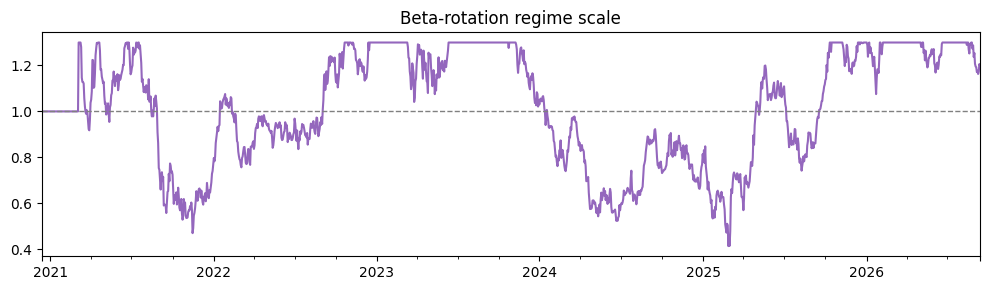

In [4]:
def compute_regime_score(regime_panel, z_window=252):
    ratios = {"XLY_XLP": (regime_panel["XLY"] / regime_panel["XLP"], 1),
              "XLU_SPY": (regime_panel["XLU"] / regime_panel["SPY"], -1),
              "RSP_SPY": (regime_panel["RSP"] / regime_panel["SPY"], 1)}
    zs = []
    for name, (ratio, sign) in ratios.items():
        z = (ratio - ratio.rolling(z_window, min_periods=60).mean()) / (ratio.rolling(z_window, min_periods=60).std() + 1e-9)
        zs.append(sign * z)
    composite = pd.concat(zs, axis=1).mean(axis=1)
    scale = (1.0 + 0.25 * composite).clip(0.3, 1.3)
    return scale.fillna(1.0)


def volume_surge_score(volume, short=VOL_SURGE_SHORT, long=VOL_SURGE_LONG):
    """Relative volume increase: short rolling avg / long rolling avg. >1 = unusually active."""
    short_avg = volume.rolling(short, min_periods=max(2, short // 2)).mean()
    long_avg = volume.rolling(long, min_periods=max(10, long // 3)).mean()
    return (short_avg / long_avg.clip(lower=1.0)).replace([np.inf, -np.inf], np.nan)


regime_scale = compute_regime_score(regime_close).reindex(common_idx).ffill().fillna(1.0)
vsurge = volume_surge_score(all_volume)

fig, ax = plt.subplots(figsize=(10, 3))
regime_scale.plot(ax=ax, color="tab:purple")
ax.axhline(1.0, color="gray", lw=1, ls="--")
ax.set_title("Beta-rotation regime scale")
plt.tight_layout(); plt.show()


## 4 — Momentum + TEMA/MACD ensemble gate + Donchian breakout

In [5]:
def momentum_score(close, lookback=MOMENTUM_LOOKBACK):
    return close / close.shift(lookback) - 1.0


def tema_vote(close, periods=TEMA_PERIODS):
    fast, mid, slow = periods
    ema_f = close.ewm(span=fast, adjust=False).mean()
    ema_m = close.ewm(span=mid, adjust=False).mean()
    ema_s = close.ewm(span=slow, adjust=False).mean()
    vote = pd.Series(0, index=close.index)
    vote[(ema_f > ema_m) & (ema_m > ema_s)] = 1
    vote[(ema_f < ema_m) & (ema_m < ema_s)] = -1
    return vote


def macd_vote(close, fast=MACD_FAST, slow=MACD_SLOW, signal=MACD_SIGNAL):
    macd_line = close.ewm(span=fast, adjust=False).mean() - close.ewm(span=slow, adjust=False).mean()
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    vote = pd.Series(0, index=close.index)
    vote[macd_line > signal_line] = 1
    vote[macd_line < signal_line] = -1
    return vote


def ensemble_state(close):
    """Binary queue: position only flips when BOTH legs agree; otherwise holds. Long-only --
    bearish agreement goes flat, not short (same convention as the standalone crypto notebook)."""
    v_t, v_m = tema_vote(close), macd_vote(close)
    state = np.zeros(len(close), dtype=int)
    current = 0
    for i in range(len(close)):
        if v_t.iloc[i] == 1 and v_m.iloc[i] == 1:
            current = 1
        elif v_t.iloc[i] == -1 and v_m.iloc[i] == -1:
            current = 0
        state[i] = current
    return pd.Series(state, index=close.index)


def donchian_upper(close, period=DONCHIAN_PERIOD):
    return close.rolling(period).max()


def ewm_std(x, span):
    a = 2.0 / (span + 1.0)
    m = x.ewm(alpha=a, adjust=False).mean()
    m2 = (x * x).ewm(alpha=a, adjust=False).mean()
    var = (m2 - m * m).clip(lower=0.0)
    bc = (2.0 - 2.0 * a) / (2.0 - a)
    return np.sqrt(var / bc)


vol_map, mom_map, ens_map, donch_map = {}, {}, {}, {}
for tkr in all_tickers:
    close_native = stock_close[tkr] if tkr in STOCK_BUCKET else crypto_close[tkr]
    ann = ANN_DAYS_MAP[tkr]
    ret_native = close_native.pct_change().fillna(0.0)
    vol_native = (ewm_std(ret_native, 30) * np.sqrt(ann)).clip(lower=0.05)
    vol_map[tkr] = vol_native.reindex(common_idx, method="ffill")
    mom_map[tkr] = momentum_score(all_close[tkr])
    ens_map[tkr] = ensemble_state(all_close[tkr])
    donch_map[tkr] = donchian_upper(all_close[tkr])

VOL = pd.DataFrame(vol_map)
MOM = pd.DataFrame(mom_map)
ENS = pd.DataFrame(ens_map)
DONCH = pd.DataFrame(donch_map)
print("Signal panels built:", VOL.shape, MOM.shape, ENS.shape, DONCH.shape)


Signal panels built: (1500, 34) (1500, 34) (1500, 34) (1500, 34)


## 5 — Weekly rotation loop

This is inherently sequential (tranche sizes are path-dependent — a Donchian add-on today
depends on whether the position was opened last week), so it's a day-by-day loop rather than a
vectorized calculation, same style as the drawdown governor in the main notebook.

In [6]:
idx = common_idx
rebal_dates = idx[::REBAL_DAYS]
weights = pd.DataFrame(0.0, index=idx, columns=all_tickers)
rotation_log = []

current_weights = pd.Series(0.0, index=all_tickers)
for day_i, d in enumerate(idx):
    if d in rebal_dates:
        current_weights[:] = 0.0                       # full exit -- weekly rotation
        vs_row = vsurge.loc[d].dropna()
        candidates = vs_row.sort_values(ascending=False).index[:VOL_SURGE_TOP_K]   # step 1+2
        ens_row = ENS.loc[d, candidates]
        eligible = ens_row[ens_row == 1].index          # step 4: ensemble hard gate
        if len(eligible) > 0:
            mom_row = MOM.loc[d, eligible].dropna()
            selected = mom_row.sort_values(ascending=False).index[:SELECT_N]        # momentum rank among eligible
            vol_row = VOL.loc[d, selected].clip(lower=0.05)
            inv_vol = 1.0 / vol_row
            tranche = INITIAL_TRANCHE * (inv_vol / inv_vol.mean()) * regime_scale.loc[d]   # step 3+5
            current_weights[selected] = tranche.clip(upper=MAX_POSITION)
            rotation_log.append({"date": d, "selected": list(selected), "n": len(selected)})
        else:
            rotation_log.append({"date": d, "selected": [], "n": 0})
    else:
        held = current_weights[current_weights > 0].index
        for tkr in held:                                 # step 5: Donchian breakout add-on
            if len(DONCH.loc[:d, tkr]) > 1 and all_close.loc[d, tkr] >= DONCH.loc[:d, tkr].iloc[-2] \
               and current_weights[tkr] < MAX_POSITION:
                addon = ADDON_TRANCHE * regime_scale.loc[d]
                current_weights[tkr] = min(MAX_POSITION, current_weights[tkr] + addon)
    weights.iloc[day_i] = current_weights.values

print(f"Rotation events: {len(rotation_log)}  |  "
      f"avg names selected per rotation: {np.mean([r['n'] for r in rotation_log]):.1f}  |  "
      f"rotations with zero eligible names: {sum(1 for r in rotation_log if r['n']==0)}")


Rotation events: 215  |  avg names selected per rotation: 4.0  |  rotations with zero eligible names: 23


## 6 — Backtest

Rotation engine  | Sharpe   0.11 | TotRet     3.3% | MaxDD  -27.7% | AvgTurnover/yr  19.5
EW basket B&H    | Sharpe   0.39 | TotRet    55.8% | MaxDD  -67.6% | AvgTurnover/yr   0.0


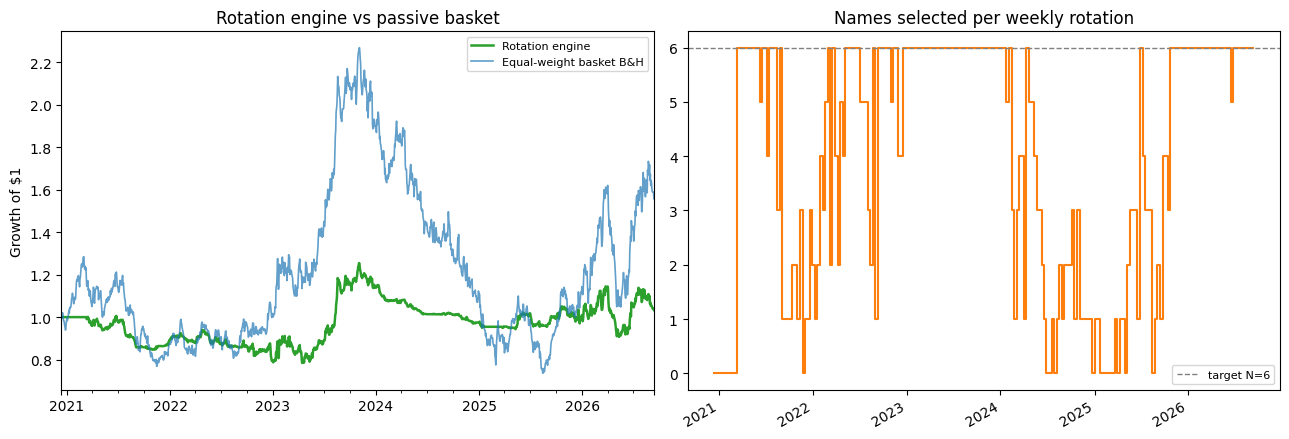

In [7]:
def backtest(close, weights, cost_bps=COST_BPS):
    rets = close.pct_change().fillna(0.0)
    pos = weights.shift(1).fillna(0.0)
    turnover = pos.diff().abs().fillna(pos.abs()).sum(axis=1)
    costs = turnover * (cost_bps / 1e4)
    port_ret = (pos * rets).sum(axis=1) - costs
    equity = (1.0 + port_ret).cumprod()
    return pd.DataFrame({"ret": port_ret, "equity": equity, "turnover": turnover})


def annualized_sharpe(r, ann_days=252):
    mu, sd = r.mean(), r.std()
    return float(np.sqrt(ann_days) * mu / sd) if sd > 0 else 0.0


def max_drawdown(equity):
    return float((equity / equity.cummax() - 1.0).min())


def report(name, bt, ann_days=252):
    sr = annualized_sharpe(bt["ret"], ann_days)
    mdd = max_drawdown(bt["equity"])
    tot = bt["equity"].iloc[-1] - 1
    print(f"{name:16s} | Sharpe {sr:6.2f} | TotRet {tot:8.1%} | MaxDD {mdd:7.1%} | "
          f"AvgTurnover/yr {bt['turnover'].mean()*ann_days:5.1f}")
    return {"sharpe": sr, "total_return": tot, "max_dd": mdd}


bt = backtest(all_close, weights)
report("Rotation engine", bt)

ew_ret = all_close.pct_change().fillna(0.0).mean(axis=1)
ew_equity = (1 + ew_ret).cumprod()
report("EW basket B&H", pd.DataFrame({"ret": ew_ret, "equity": ew_equity, "turnover": pd.Series(0.0, index=ew_ret.index)}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
bt["equity"].plot(ax=axes[0], label="Rotation engine", lw=1.8, color="tab:green")
ew_equity.plot(ax=axes[0], label="Equal-weight basket B&H", lw=1.2, alpha=0.7)
axes[0].set_title("Rotation engine vs passive basket"); axes[0].legend(fontsize=8)
axes[0].set_ylabel("Growth of $1")

n_selected = pd.Series([r["n"] for r in rotation_log], index=[r["date"] for r in rotation_log])
n_selected.plot(ax=axes[1], drawstyle="steps-post", color="tab:orange")
axes[1].axhline(SELECT_N, color="gray", ls="--", lw=1, label=f"target N={SELECT_N}")
axes[1].set_title("Names selected per weekly rotation"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


In [8]:
recent = pd.DataFrame(rotation_log[-8:])
print("Most recent 8 rotations:")
for _, row in recent.iterrows():
    print(f"  {row['date'].date()}: {row['selected'] if row['selected'] else '(none eligible -- fully flat this week)'}")


Most recent 8 rotations:
  2026-07-03: ['BA', 'KO', 'NVDA', 'AMZN', 'META', 'XOM']
  2026-07-14: ['ADA-USD', 'BA', 'PG', 'CVX', 'ABBV', 'JNJ']
  2026-07-23: ['ADA-USD', 'PG', 'CVX', 'ABBV', 'AMZN', 'V']
  2026-08-03: ['KO', 'SOL-USD', 'CVX', 'META', 'AMD', 'BA']
  2026-08-12: ['UNH', 'V', 'MSFT', 'AMD', 'BA', 'XOM']
  2026-08-21: ['SOL-USD', 'CVX', 'KO', 'V', 'AVGO', 'HON']
  2026-09-01: ['SOL-USD', 'MSFT', 'AVGO', 'META', 'UNH', 'HON']
  2026-09-10: ['JNJ', 'CVX', 'KO', 'ABBV', 'V', 'AMD']


## 7 — Honest limitations

- **Volume/attention scope.** As stated up front: this ranks the 34-name vetted bucket by its
  own relative volume, it does not scan the broader market for surges and then filter down. A
  production version needs a market-wide screener feed for step 1 to mean what it sounds like
  it means.
- **Still synthetic data** — same network caveat as every other notebook in this session; see
  the main engine's Section 1 for exactly how to run this with real data.
- **No drawdown governor in this notebook.** The 10%-target governor from the main engine
  (daily VaR cap + trailing throttle + cooldown/ramp) is a separate, complementary layer that
  would sit on top of the weights this notebook produces — it was deliberately left out here to
  keep this pipeline's own logic legible, not because it's unnecessary for real capital.
- **Weekly full-exit cost sensitivity.** Closing and rebuilding the whole book every 7 days
  means turnover — and therefore cost drag — is structurally higher than the main engine's
  hold-between-rebalances approach. `COST_BPS` here is a placeholder; real crypto spreads
  (especially on the smaller majors like ADA/XRP/LTC) can run wider than assumed, and that
  would show up disproportionately in a strategy that trades this often.
- **Donchian add-ons are lost at every rotation by design** — this was the literal request
  ("on the rebalance weekly we exit and rotate capital"), but it does mean a name that broke out
  strongly on day 6 of a 7-day cycle gets flattened almost immediately regardless of how well
  the breakout was working. Worth knowing that trade-off exists before assuming weekly rotation
  is strictly better than letting winners run past the rotation boundary.
